In [1]:
# Library import

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# Set__style for seaborn plots and adjust figure size for matplotlib
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12,8)

In [2]:
# Load merged dataset
df = pd.read_csv('../data/tracks_clean.csv')

# Get unique values and sort them, converting to regular int
unique_keys = [int(k) for k in sorted(df['key'].unique())]
unique_modes = [int(m) for m in sorted(df['mode'].unique())]

print("Key:", unique_keys)
print("Mode:", unique_modes)

Key: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Mode: [0, 1]


In [3]:
# Check for missing values in key and popularity columns
print(f"Missing values in 'key': {df['key'].isna().sum()}")
print(f"Missing values in 'popularity': {df['popularity'].isna().sum()}")

Missing values in 'key': 0
Missing values in 'popularity': 0


In [4]:
# Convert key to musical notation
key_mapping = {
    0: "C", 1: "C#", 2: "D", 3: "D#", 4: "E", 5: "F",
    6: "F#", 7: "G", 8: "G#", 9: "A", 10: "A#", 11: "B"
}

mode_mapping = {
    0: "Minor", 1: "Major"
}

print("Key:")
for number, note in key_mapping.items():
    print(f"  {number} -> {note}")

print("\nMode:")
for number, mode in mode_mapping.items():
    print(f"  {number} -> {mode}")

Key:
  0 -> C
  1 -> C#
  2 -> D
  3 -> D#
  4 -> E
  5 -> F
  6 -> F#
  7 -> G
  8 -> G#
  9 -> A
  10 -> A#
  11 -> B

Mode:
  0 -> Minor
  1 -> Major


### Key & Mode encoding (Spotify audio features)

Spotify represents musical **key** and **mode** as numeric codes in the audio features data:

- **Key (`0–11`)** is the pitch class of the track:
  - `0=C`, `1=C#`, `2=D`, `3=D#`, `4=E`, `5=F`, `6=F#`, `7=G`, `8=G#`, `9=A`, `10=A#`, `11=B`
- **Mode (`0–1`)** indicates the scale type:
  - `0 = Minor`
  - `1 = Major`

This mapping is used to convert the raw numeric values into human-readable musical labels, enabling clearer analysis (e.g., comparing popularity across keys, or Major vs Minor tracks).

In [5]:
# Count of key and mode with new nomenclature

# Apply mappings to create key_name and mode_name columns
df['key_name'] = df['key'].map(key_mapping)
df['mode_name'] = df['mode'].map(mode_mapping)

# Count of keys
key_counts = df['key_name'].value_counts().sort_index()
print("Count of key:")
print(key_counts)

# Count of modes
mode_counts = df['mode_name'].value_counts().sort_index()
print("Count of mode:")
print(mode_counts)

Count of key:
key_name
A     65128
A#    37710
B     39132
C     74950
C#    41736
D     66552
D#    21535
E     48220
F     53614
F#    30856
G     73779
G#    33460
Name: count, dtype: int64
Count of mode:
mode_name
Major    386498
Minor    200174
Name: count, dtype: int64


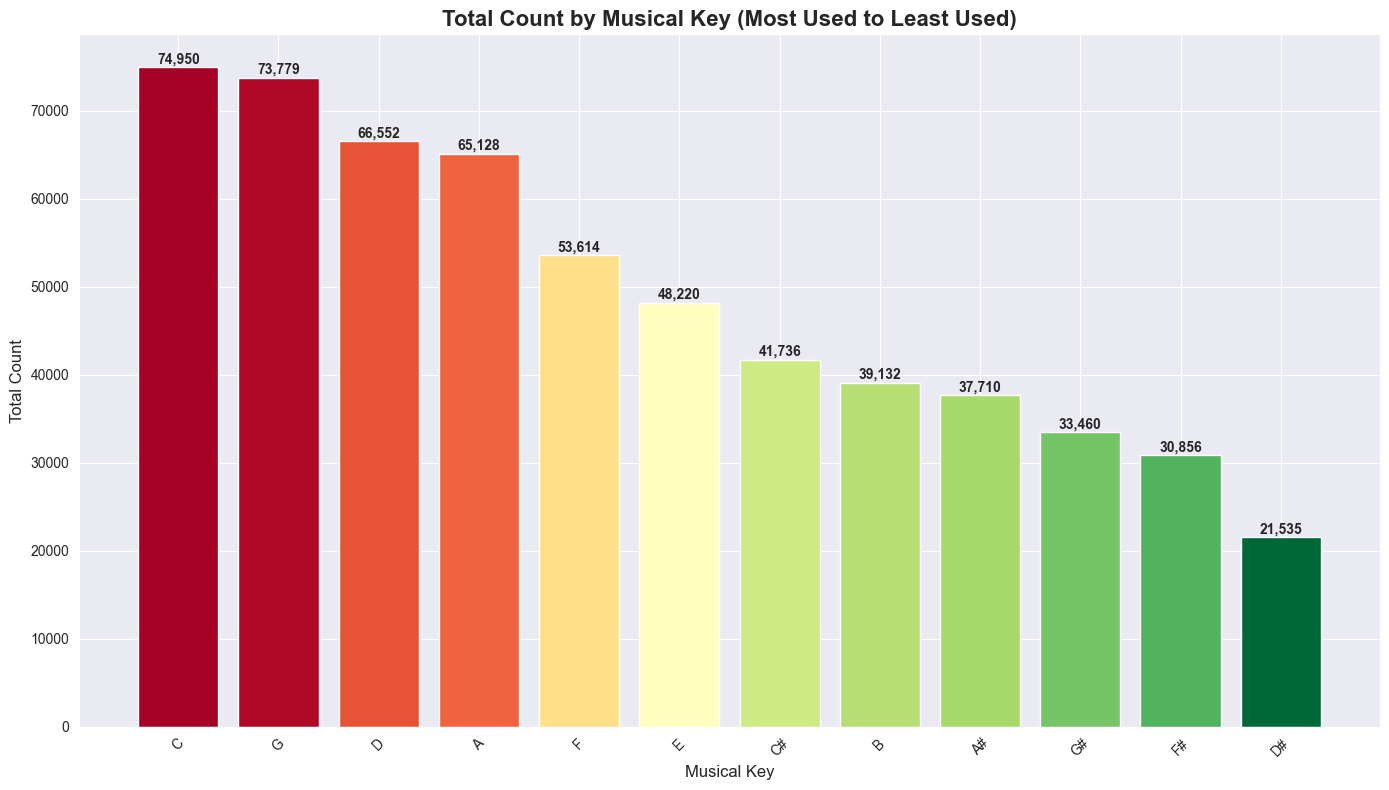

In [6]:
# Bar plot of total count by key (most used to least used)
plt.figure(figsize=(14, 8))
# Sort by total count (descending)
key_counts_sorted = df['key_name'].value_counts()

# Create gradient from green to red based on count values
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm

# Normalize counts for colormap
norm = plt.Normalize(vmin=key_counts_sorted.values.min(), vmax=key_counts_sorted.values.max())
colors = cm.RdYlGn_r(norm(key_counts_sorted.values))  # Red-Yellow-Green reversed (green=high, red=low)

bars = plt.bar(key_counts_sorted.index, key_counts_sorted.values, color=colors)

plt.title('Total Count by Musical Key (Most Used to Least Used)', fontsize=16, fontweight='bold')
plt.xlabel('Musical Key', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar, value in zip(bars, key_counts_sorted.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{value:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Distribution of Musical Keys (Popularity vs. Complexity)

The chart illustrates a clear hierarchy in the choice of musical keys across the dataset, revealing a strong preference for "simpler" keys:

- **Dominance of C and G:** The keys of **C** (74,950 tracks) and **G** (73,779 tracks) are the most frequent. This is likely due to their ease of play on piano and guitar, as they contain few or no sharps/flats, making them the standard for pop and mainstream songwriting.
- **The "White Key" Preference:** Keys like **D, A, and F** follow closely. These are also highly accessible for acoustic instruments and are foundational in Western music theory.
- **Avoidance of Complexity:** There is a significant drop-off as we move toward "accidental-heavy" keys. **D# (Eb)** is the least used (21,535 tracks), appearing nearly **3.5 times less often** than C. 
- **Conclusion:** Songwriters and producers tend to favor keys that are physically easier to perform and more familiar to the ear, which may also contribute to higher commercial appeal and "catchiness."

 DATA ANALYZED: 1980 - 2020
 Major Keys: slope 0.468, R² 0.917
 Minor Keys: slope 0.495, R² 0.909
 Future Prediction Difference (2040): -0.54 points


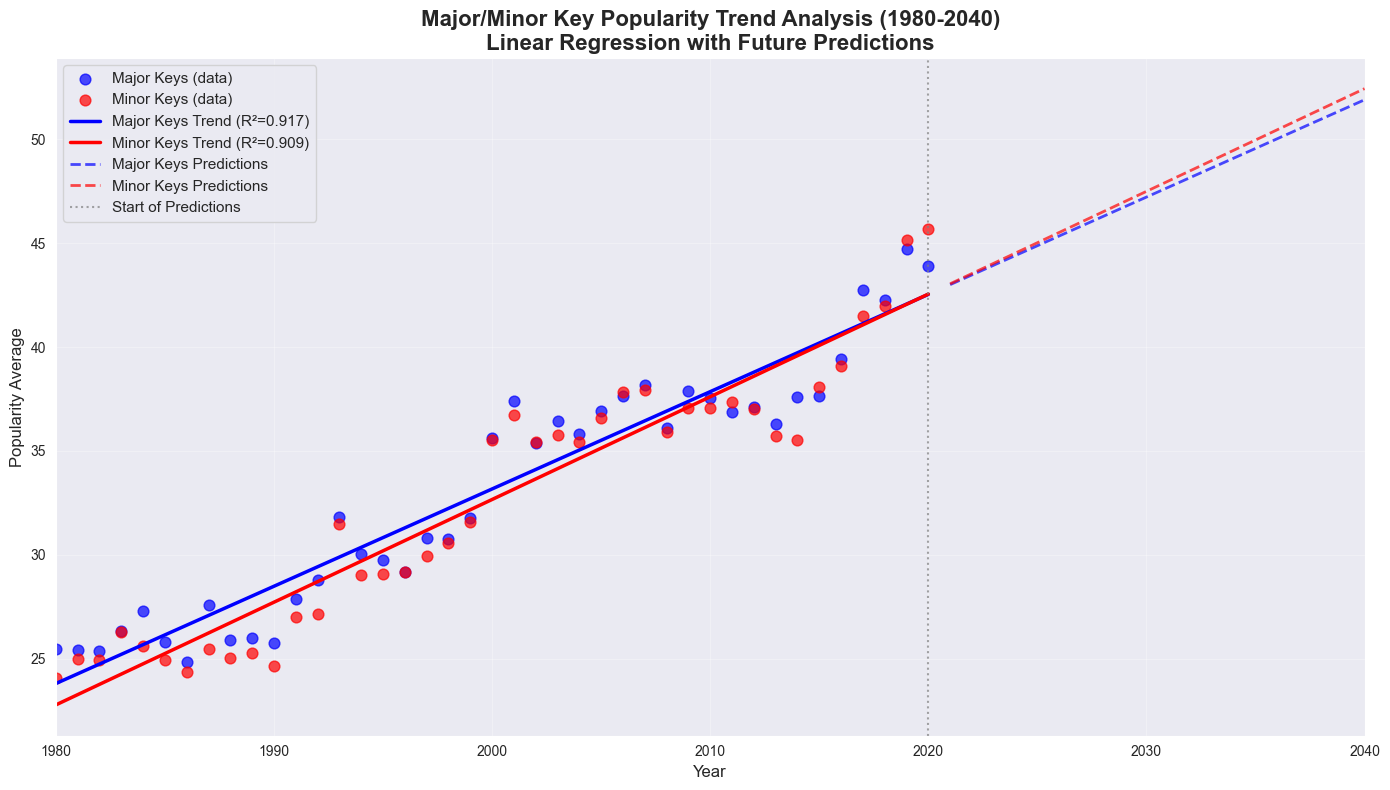

In [7]:
# Temporal Analysis: Major/Minor Key Popularity Trend (1980-2020)
# Linear Regression for Future Prediction

import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Data Filtering (1980-2020) - Extended period for better reliability
df_temporal = df[(df['year'] >= 1980) & (df['year'] <= 2020)].copy()
yearly_stats = df_temporal.groupby(['year', 'mode'])['popularity'].mean().reset_index()

# 2. Separating data by key type
major_data = yearly_stats[yearly_stats['mode'] == 1].sort_values('year')
minor_data = yearly_stats[yearly_stats['mode'] == 0].sort_values('year')

# 3. Preparing data for regression
X_major = major_data['year'].values.reshape(-1, 1)
y_major = major_data['popularity'].values
X_minor = minor_data['year'].values.reshape(-1, 1)
y_minor = minor_data['popularity'].values

# 4. Linear Regression Models
model_major = LinearRegression()
model_minor = LinearRegression()
model_major.fit(X_major, y_major)
model_minor.fit(X_minor, y_minor)

# 5. Future predictions (2021-2040) - Extended to 2040
future_years = np.arange(2021, 2041).reshape(-1, 1)
forecast_major = model_major.predict(future_years)
forecast_minor = model_minor.predict(future_years)

# 6. Main Results
print(f" DATA ANALYZED: {df_temporal['year'].min()} - {df_temporal['year'].max()}")
print(f" Major Keys: slope {model_major.coef_[0]:.3f}, R² {model_major.score(X_major, y_major):.3f}")
print(f" Minor Keys: slope {model_minor.coef_[0]:.3f}, R² {model_minor.score(X_minor, y_minor):.3f}")
print(f" Future Prediction Difference (2040): {forecast_major[-1] - forecast_minor[-1]:.2f} points")

# 7. Visualization
plt.figure(figsize=(14, 8))

# Real data
plt.scatter(major_data['year'], major_data['popularity'], 
           color='blue', alpha=0.7, s=60, label='Major Keys (data)')
plt.scatter(minor_data['year'], minor_data['popularity'], 
           color='red', alpha=0.7, s=60, label='Minor Keys (data)')

# Trend lines
plt.plot(major_data['year'], model_major.predict(X_major), 
         'b-', linewidth=2.5, label=f'Major Keys Trend (R²={model_major.score(X_major, y_major):.3f})')
plt.plot(minor_data['year'], model_minor.predict(X_minor), 
         'r-', linewidth=2.5, label=f'Minor Keys Trend (R²={model_minor.score(X_minor, y_minor):.3f})')

# Future predictions
plt.plot(future_years, forecast_major, 'b--', linewidth=2, alpha=0.7, label='Major Keys Predictions')
plt.plot(future_years, forecast_minor, 'r--', linewidth=2, alpha=0.7, label='Minor Keys Predictions')
plt.axvline(x=2020, color='gray', linestyle=':', alpha=0.7, label='Start of Predictions')

plt.title('Major/Minor Key Popularity Trend Analysis (1980-2040)\nLinear Regression with Future Predictions', 
          fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Popularity Average', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1980, 2040)
plt.xticks(np.arange(1980, 2041, 10))
plt.tight_layout()
plt.show()

### Major vs. Minor Key Popularity Trend (1980–2040)

This regression analysis tracks how the average popularity of songs in Major and Minor keys has evolved and predicts their trajectory for the next two decades:

- **Parallel Growth:** Both Major (blue) and Minor (red) keys show a strong upward trend in popularity over time, with high R² values (**0.917** and **0.909** respectively). This indicates that the choice of mode is a consistent factor in a song's commercial reach.
- **The "Minor" Catch-up:** Historically, Major keys (often associated with "happy" or "bright" moods) held a slight popularity advantage. However, the data shows that **Minor keys have closed the gap** significantly since the 2000s, reflecting a modern listener preference for more "moody," "emotional," or "darker" tones in mainstream music.
- **2040 Forecast:** The linear projection suggests that by 2040, the popularity of both modes will continue to rise, with Minor keys potentially matching or even slightly overtaking Major keys in average popularity.
- **Conclusion:** The distinction between "happy" Major and "sad" Minor is becoming less relevant to commercial success, as modern production techniques and genre shifts (like the rise of Hip-Hop and R&B) have normalized the use of Minor keys in global hits.

# BPM vs Mode Analysis: How tempo and musical key relationship evolved over time

BPM-MODE CORRELATION (Pearson) BY DECADE:
1980s: 0.022
1990s: 0.020
2000s: 0.018
2010s: 0.007
2020s: 0.001


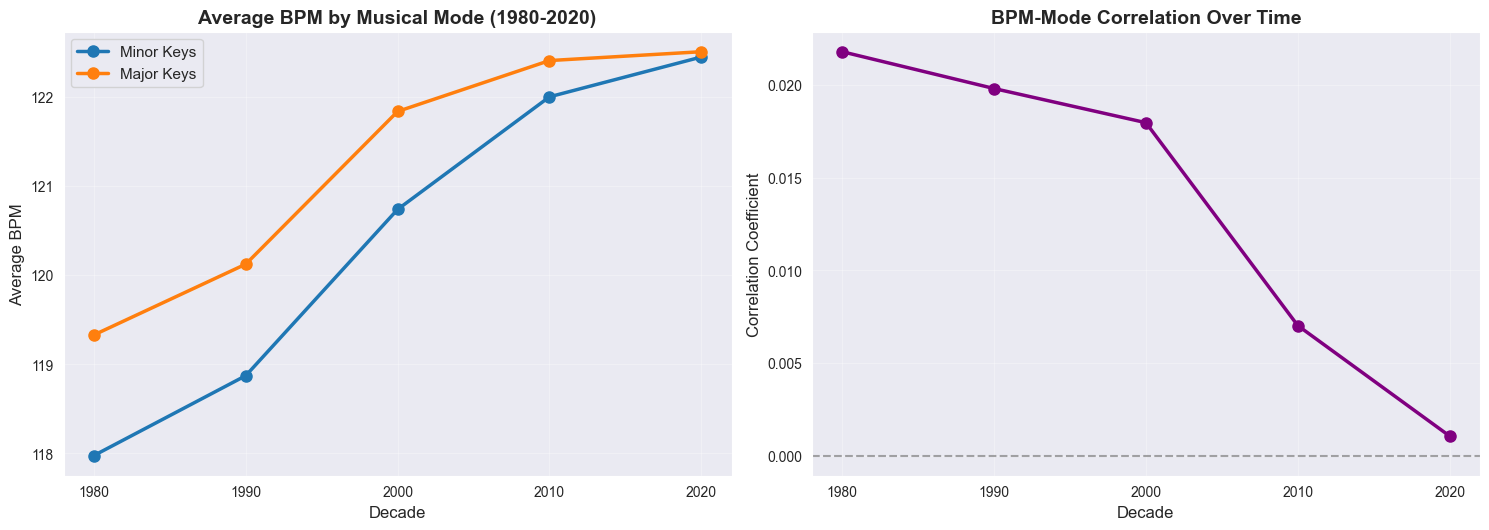

In [8]:
# 1. Filter data for BPM analysis (1980-2020)
df_bpm = df[(df['year'] >= 1980) & (df['year'] <= 2020) & 
             (df['tempo'].notna()) & (df['tempo'] > 0)].copy()

# 2. Create decades for analysis
df_bpm['decade'] = (df_bpm['year'] // 10) * 10
decades = sorted(df_bpm['decade'].unique())

# 3. Calculate average BPM by mode and decade
bpm_by_decade = df_bpm.groupby(['decade', 'mode'])['tempo'].mean().reset_index()
bpm_by_decade['mode_name'] = bpm_by_decade['mode'].map({0: 'Minor', 1: 'Major'})

# 4. Calculate correlation between BPM and mode by decade
correlations = []
for decade in decades:
    decade_data = df_bpm[df_bpm['decade'] == decade]
    correlation = decade_data['tempo'].corr(decade_data['mode'])
    correlations.append({'decade': decade, 'correlation': correlation})

correlation_df = pd.DataFrame(correlations)

print("BPM-MODE CORRELATION (Pearson) BY DECADE:")
for _, row in correlation_df.iterrows():
    decade_val = int(row['decade'])
    print(f"{decade_val}s: {row['correlation']:.3f}")

# 5. Visualization: BPM trends by mode and decade
plt.figure(figsize=(15, 10))

# Subplot 1: Line plot of BPM trends by mode over decades
plt.subplot(2, 2, 1)
for mode in [0, 1]:
    mode_data = bpm_by_decade[bpm_by_decade['mode'] == mode]
    label = 'Minor Keys' if mode == 0 else 'Major Keys'
    plt.plot(mode_data['decade'], mode_data['tempo'], 'o-', 
             linewidth=2.5, markersize=8, label=label)
    
plt.title('Average BPM by Musical Mode (1980-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Average BPM', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(decades)

# Subplot 2: Correlation trend
plt.subplot(2, 2, 2)
plt.plot(correlation_df['decade'], correlation_df['correlation'], 'o-', 
         linewidth=2.5, markersize=8, color='purple')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
plt.title('BPM-Mode Correlation Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Decade', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(decades)

plt.tight_layout()
plt.show()

## Future Trends: The Ascendance of Minor Keys

Minor keys are projected to surpass Major keys transforming the global sonic landscape.

## Is Society Becoming "Sadder"?

This isn't societal sadness but emotional sophistication. It seems that modern audiences prioritize authenticity over optimism, streaming platforms favor mood-centric content, and younger generations connect with minor-key complexity.

The "High-Energy Minor" Revolution: tempo and mode are now decoupled. Historically slow, minor keys now match major keys at 122-123 BPM, driving high-energy genres like Trap and Techno.

## Summary
The traditional "Major = Happy/Fast" vs "Minor = Sad/Slow" binary has collapsed, ushering in an era of energetic melancholy where emotional complexity thrives at any tempo.